In [1]:
from functools import partial
from rpy2.ipython import html
html.html_rdataframe=partial(html.html_rdataframe, table_class="docutils")

# Data Import

We choose to use an external dataset to demonstrate how R's own data import
features can be used.

In [2]:
from rpy2.robjects.packages import importr
utils = importr('utils')

dataf = utils.read_csv('https://raw.githubusercontent.com/jakevdp/PythonDataScienceHandbook/'
                       'master/notebooks_v1/data/california_cities.csv')

The objects returned by R's own `read.csv()` function (note that the R function
in the R package `utils` is called `read.csv()` while the Python function is called
`read_csv()` - `rpy2` converts R symbols with dots to underscores for Python).

`rpy2` provides customization to display R objects such as data frames in HTML
in a notebook. That customization is enabled as follows:

In [3]:
import rpy2.ipython.html
rpy2.ipython.html.init_printing()

In [4]:
dataf

,,X,city,latd,longd,...,area_water_km2,area_water_percent
0,1,0,Adelanto,34.57611111111112,-117.43277777777779,...,0.046,0.03
1,2,1,AgouraHills,34.15333333333333,-118.76166666666667,...,0.076,0.37
2,3,2,Alameda,37.75611111111111,-122.27444444444444,...,31.983,53.79
3,4,3,Albany,37.886944444444445,-122.29777777777778,...,9.524,67.28
4,5,4,Alhambra,34.081944444444446,-118.135,...,0.003,0.01
5,6,5,AlisoViejo,33.575,-117.72555555555556,...,0.0,0.0
6,7,6,Alturas,41.48722222222222,-120.5425,...,0.036000000000000004,0.57
7,8,7,AmadorCity,38.419444444444444,-120.82416666666666,...,0.0,0.0
...,...,...,...,...,...,...,...,...
480,481,480,Yucaipa,34.030277777777776,-117.04861111111111,...,0.013000000000000001,0.02


In [5]:
dataf.colnames

X,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,...,area_water_km2,area_water_percent


In [6]:
stats = importr('stats')
base = importr('base')
fit = stats.lm('elevation_m ~ latd + longd', data=dataf)
fit

0,coefficients,(Intercep...
1,residuals,...
2,effects,...
3,rank,[1] 3
4,fitted.values,...
5,assign,[1] 0 1 2
6,qr,$qr ...
7,df.residual,[1] 431
...,...,...
11,terms,elevation...
12,model,...


# Graphics

R has arguably some the best static visualizations, often looking more polished
than other visualization systems and this without the need to spend much
effort on them.

## Using `ggplot2`

Among R visulization pacakges, `ggplot2` has emerged as something Python users
wished so much they had that various projects to try port it to Python
are regularly started.

However, the best way to have `ggplot2` might be to use `ggplot2` from Python.

In [7]:
import rpy2.robjects.lib.ggplot2 as gp

R lets is function parameters be unevaluated language objects, which is fairly different
from Python's immediate evaluation. `rpy2` has a utility code to create such R language
objects from Python strings.
It can then become very easy to mix Python and R, with R like a domain-specific language
used from Python.

In [8]:
from rpy2.robjects import rl

Calling `ggplot2` looks pretty much like it would in R, which allows one to use the
all available documentation and examples available for the R package. Remember that
this is not a reimplementation of ggplot2 with inevitable differences and delay
for having the latest changes: the R package itself is generating the figures.

In [9]:
p = (gp.ggplot(dataf) +
     gp.aes(x=rl('longd'),
            y=rl('latd'),
            color=rl('population_total'),
            size=rl('area_total_km2')) +
     gp.geom_point() +
     gp.scale_color_continuous(trans='log10'))

Plotting the resulting R/ggplot2 object into the output cell of a notebook, is just
function call away.

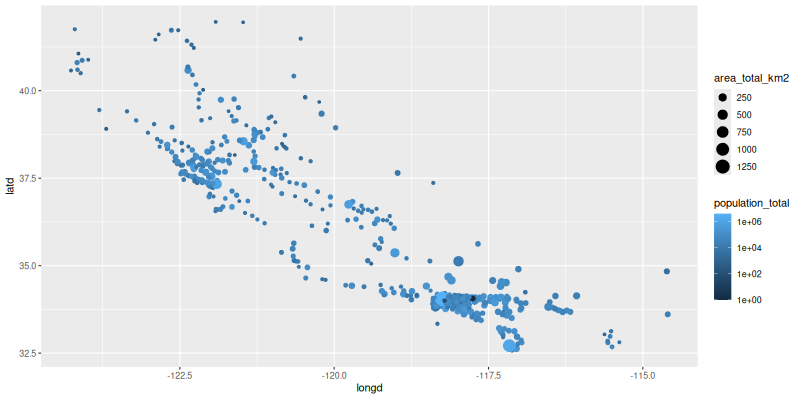

In [10]:
from rpy2.ipython.ggplot import image_png
image_png(p)

All features from `ggplot2` should be present. A more complex example to
get the figure we want is:

R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`). 
  


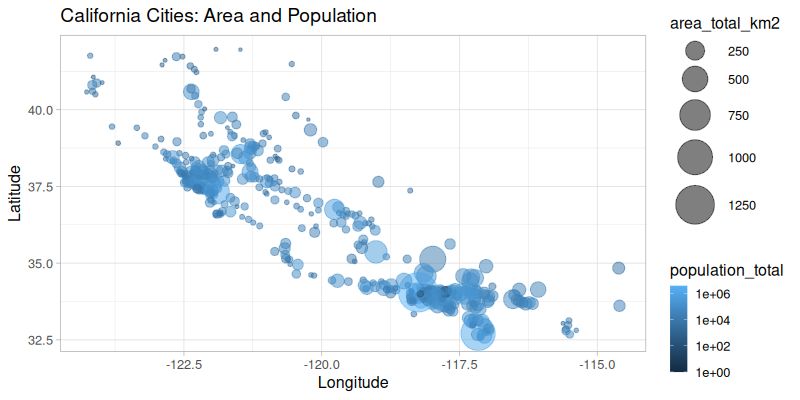

In [11]:
from rpy2.robjects.vectors import IntVector
p = (gp.ggplot(dataf) +
     gp.aes(x=rl('longd'),
            y=rl('latd'),
            color=rl('population_total'),
            size=rl('area_total_km2')) +
     gp.geom_point(alpha=0.5) +
     # Axis definitions.
     gp.scale_x_continuous('Longitude') +
     gp.scale_y_continuous('Latitude') +
     # Custom size range.
     gp.scale_size(range=IntVector([1, 18])) +
     # Transform for pop -> color mapping
     gp.scale_color_continuous(trans='log10') +
     # Title.
     gp.ggtitle('California Cities: Area and Population') +
     # Plot theme and text size.
     gp.theme_light(base_size=16))
image_png(p)

## Using `ggplot2` extensions

There existing additional R packages extending `ggplot2`, and while it would be impossible
for the rpy2 to provide wrapper for all of them the wrapper for `ggplot2` is based
on class hierarchies that should make the use of such extensions really easy.

For example, to use the viridis color scale, we just need to import the corresponding R package,
and write 3 lines of Python to extend `rpy2`'s ggplot2 wrapper with a new color scale. A clas
diagram with the classes in the rpy2 wrapper for ggplot2 is available in the rpy2 documentation.

In [12]:
viridis = importr('viridis')
class ScaleColorViridis(gp.ScaleColour):
    _constructor = viridis.scale_color_viridis
scale_color_viridis = ScaleColorViridis.new

That new color scale can then be used as any other scale already present in `ggplot2`:

R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`). 
  


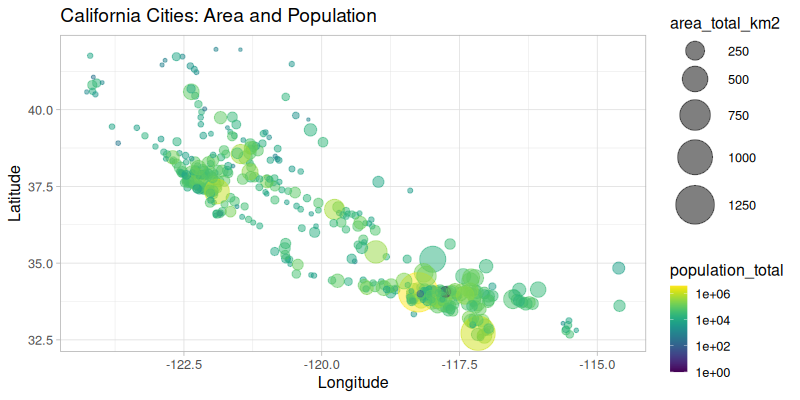

In [13]:
p = (gp.ggplot(dataf) +
     gp.aes(x=rl('longd'),
            y=rl('latd'),
            color=rl('population_total'),
            size=rl('area_total_km2')) +
     gp.geom_point(alpha=0.5) +
     gp.scale_x_continuous('Longitude') +
     gp.scale_y_continuous('Latitude') +
     gp.scale_size(range=IntVector([1, 18])) +
     scale_color_viridis(trans='log10') +
     gp.ggtitle('California Cities: Area and Population') +
     gp.theme_light(base_size=16))
image_png(p)

# R "magics"

So far we have shown that using `ggplot2` can be done from Python as if it
was just an other Python library for visualization, but R can also be used
in cells.

First the so-called "R magic" extensions should be loaded.

In [14]:
%load_ext rpy2.ipython

From now on, code cells starting with `%%R` will see their content evaluated as R code.
If the R code is generating figures, they will be displayed along with the rest of the output.

In [15]:
%%R
R.version.string

[1]

 "R version 4.5.3 (2026-03-11)"

In addition: Warning message:
Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`). 


In [16]:
%%R -i dataf

require(dplyr)
glimpse(dataf)

Rows: 482

Columns: 14

$ X                  <int> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1…
$ city               <chr> "Adelanto", "AgouraHills", "Alameda", "Albany", "Al…
$ latd               <dbl> 34.57611, 34.15333, 37.75611, 37.88694, 34.08194, 3…
$ longd              <dbl> -117.4328, -118.7617, -122.2744, -122.2978, -118.13…
$ elevation_m        <dbl> 875, 281, NA, NA, 150, 127, 1332, 280, 14, 48, 132,…
$ elevation_ft       <dbl> 2871, 922, 33, 43, 492, 417, 4370, 919, 46, 157, 43…
$ population_total   <int> 31765, 20330, 75467, 18969, 83089, 47823, 2827, 185…
$ area_total_sq_mi   <dbl> 56.027, 7.822, 22.960, 5.465, 7.632, 7.472, 2.449, …
$ area_land_sq_mi    <dbl> 56.009, 7.793, 10.611, 1.788, 7.631, 7.472, 2.435, …
$ area_water_sq_mi   <dbl> 0.018, 0.029, 12.349, 3.677, 0.001, 0.000, 0.014, 0…
$ area_total_km2     <dbl> 145.107, 20.260, 59.465, 14.155, 19.766, 19.352, 6.…
$ area_land_km2      <dbl> 145.062, 20.184, 27.482, 4.632, 19.763, 19.352, 6.3…
$ area_water_km2     <dbl> 0.046, 0.076,

Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



The data frame called `dataf` in our Python notebook was already bound to the name
`dataf` in the R main namespace (`GlobalEnv` in the R lingo) in our previous cell.
We can just use it in subsequent cells.

Running an R code cell.


In addition: Warning message:
Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`). 


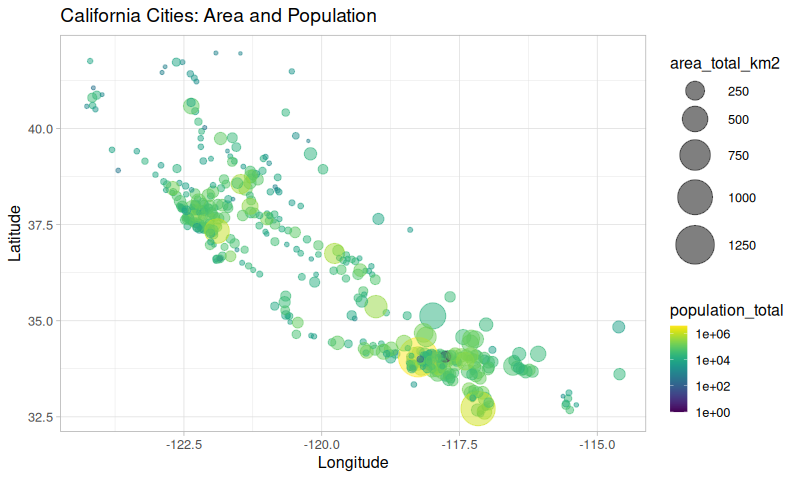

In [17]:
%%R -w 800 --type=cairo

cat("Running an R code cell.\n")

p <- ggplot(dataf) +
     aes(x=longd,
         y=latd,
         color=population_total,
         size=area_total_km2) +
     geom_point(alpha=0.5) +
     scale_x_continuous('Longitude') +
     scale_y_continuous('Latitude') +
     scale_size(range=c(1, 18)) +
     scale_color_viridis(trans='log10') +
     ggtitle('California Cities: Area and Population') +
     theme_light(base_size=16)
print(p)

## Options.

The R "magics" use a number of configurable options that control
aspects of the interaction between Python and R, or between ipython / jupyter
and R. Some of the options can specified through arguments to "magics",
but it is also possible to configure the default value for some of them
when an argument to a "magic" does not specify otherwise. The easiest
way to list these default-configurable options can be achieved
with a "magic":

In [18]:
%Roptions show

Default settings for R magics.
------------------------------
  - graphics device
      requested: png
      found: grDevices::png
        <rpy2.ipython.rmagic.GraphicsDeviceRaster object at 0x7ff0e4b11630>: 
        grDevices::png 
        (extension: png)
        Options and default values:
          width: None
          height: None
          pointsize: None
          bg: None
          units: None
          res: None
  - converter
    <class 'rpy2.robjects.conversion.Converter'>
    py2rpy
    - builtins.object
    - rpy2.rinterface._MissingArgType
    - builtins.bool
    - builtins.int
    - builtins.float
    - builtins.bytes
    - builtins.str
    - rpy2.robjects.robject.RObject
    - rpy2.rinterface_lib.sexp.Sexp
    - array.array
    - builtins.list
    - rpy2.rlike.container.TaggedList
    - rpy2.rlike.container.NamedList
    - builtins.complex
    - builtins.function
    - numpy.ndarray
    - numpy.integer
    - numpy.floating
    - rpy2.rlike.container.OrdDict
    - pandas

Changing these defaults requires to modify components of the attribute
:attr:`rpy2.ipython.rmagic.RMagic.options`. Here is an example showing
how to changing the default of R figures rendered in the notebook to "svg".

In [19]:
import IPython
ipy = IPython.get_ipython()
ipy.magics_manager.registry['RMagics'].options.graphics_device_name = 'svg'

Another example is how to change conversion rules, that can be
an expensive operation depending object sizes and rules, to a no-op:
no convertion rules to keep all rpy2 objects as proxy wrappers
to R objects for example, no conversion of Python objects to R:

In [20]:
import rpy2.robjects
import IPython
ipy = IPython.get_ipython()

noop_conv = rpy2.robjects.conversion.Converter('No-Op')
noop_conv.rpy2py.register(rpy2.robjects.RObject,
                          rpy2.robjects._rpy2py_robject)

ipy.magics_manager.registry['RMagics'].options.converter = noop_conv

Modifying this come with risks though, or afterthoughts about changes made.
While there are some checks in place, the new default options set this way
may break the R "magics".
To address this, options can be restore to
"factory settings". Here again, there is no guarantee that this can work no
matter what. A driven
(or unlucky) user may break this mechanism if modifying it in the module.
Restarting kernel will be needed in that case.

In [21]:
%Roptions refresh

## Graphics devices

Graphics devices can be specified precisely as a function in an R namespace.
For example, "grDevices:png". It is also possible to specify a generic graphical
device name that is a sequence of graphics devices to try. The first one in that
sequence that appears to be functioning is then selected.

For example, this is the case when
the graphics device option is set to "svg". The R package `svglite` is
the first to try in the sequence. If R fails to load that package there
are other  SVG devices to try try as alternatives.

To demonstrate this, let's set the graphics devices to "svg":

In [22]:
import IPython
ipy = IPython.get_ipython()
ipy.magics_manager.registry['RMagics'].options.graphics_device_name = 'svg'

The output of the following magic depends on the R
packages installed on your system. If the R package `svglite` is installed
its device will be used. Otherwise alternatives will be tried.

In [23]:
%Roptions show

Default settings for R magics.
------------------------------
  - graphics device
      requested: svg
      found: grDevices::svg
        <rpy2.ipython.rmagic.GraphicsDeviceSVG object at 0x7ff0c4859b10>: 
        grDevices::svg 
        (extension: svg)
        Options and default values:

  - converter
    <class 'rpy2.robjects.conversion.Converter'>
    py2rpy
    - builtins.object
    - rpy2.rinterface._MissingArgType
    - builtins.bool
    - builtins.int
    - builtins.float
    - builtins.bytes
    - builtins.str
    - rpy2.robjects.robject.RObject
    - rpy2.rinterface_lib.sexp.Sexp
    - array.array
    - builtins.list
    - rpy2.rlike.container.TaggedList
    - rpy2.rlike.container.NamedList
    - builtins.complex
    - builtins.function
    - numpy.ndarray
    - numpy.integer
    - numpy.floating
    - rpy2.rlike.container.OrdDict
    - pandas.core.frame.DataFrame
    - pandas.core.indexes.base.Index
    - pandas.core.arrays.categorical.Categorical
    - pandas.core.series.S

### Options for graphics device

Graphics devices, selected from a generic names when the case (see above),
may havee options. These options can be specific to each graphics device.

**note: this is prefixed with an underscore to indicate that the API is
subject to changes.**

Options to display graphics are under `_options_display`. For example,
to change the default width:

In [24]:
(
    ipy.magics_manager.registry['RMagics'].graphics_device
    ._options_display
    .width
) = 10